<a href="https://colab.research.google.com/github/basualdoimportante-boop/proyecto2-analisis-datos/blob/main/EDA_dataset2_meditacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# ============================================================
# CELDA 1 — Autenticación con Kaggle y Descarga del Dataset
# ============================================================

import os
import kagglehub

# Credenciales de API Heredadas (Legacy API Credentials)
os.environ['KAGGLE_USERNAME'] = 'basualdoimportante'
os.environ['KAGGLE_KEY'] = '23be7bb105d2e86189a0111926cb3fe3'

# Descarga del dataset de factores de estrés estudiantil
# Student Stress Factors - A Comprehensive Analysis
# (Factores de Estrés Estudiantil - Un Análisis Comprehensivo)
path = kagglehub.dataset_download('rxnach/student-stress-factors-a-comprehensive-analysis')

print(f"Dataset descargado en: {path}")

100%|██████████| 11.7k/11.7k [00:00<00:00, 14.6MB/s]

Extracting files...
Dataset descargado en: /root/.cache/kagglehub/datasets/rxnach/student-stress-factors-a-comprehensive-analysis/versions/1


In [7]:
# ============================================================
# CELDA 2 — Verificar archivos disponibles
# ============================================================

import os

ruta = '/root/.cache/kagglehub/datasets/rxnach/student-stress-factors-a-comprehensive-analysis/versions/1'

print("=== ARCHIVOS DISPONIBLES ===")
for archivo in os.listdir(ruta):
    print(archivo)


=== ARCHIVOS DISPONIBLES ===
StressLevelDataset.csv


In [8]:
# ============================================================
# CELDA 3 — Carga del Dataset e Inspección Inicial
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset de factores de estrés estudiantil
ruta = '/root/.cache/kagglehub/datasets/rxnach/student-stress-factors-a-comprehensive-analysis/versions/1'
df = pd.read_csv(f'{ruta}/StressLevelDataset.csv')

print("=== FORMA DEL DATASET (Shape) ===")
print(f"Filas (Rows): {df.shape[0]} | Columnas (Columns): {df.shape[1]}")

print("\n=== PRIMERAS 5 FILAS (Head) ===")
print(df.head())

print("\n=== TIPOS DE DATOS (Data Types) ===")
print(df.dtypes)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS (Descriptive Statistics) ===")
print(df.describe())

=== FORMA DEL DATASET (Shape) ===
Filas (Rows): 1100 | Columnas (Columns): 21

=== PRIMERAS 5 FILAS (Head) ===
   anxiety_level  self_esteem  mental_health_history  depression  headache  \
0             14           20                      0          11         2   
1             15            8                      1          15         5   
2             12           18                      1          14         2   
3             16           12                      1          15         4   
4             16           28                      0           7         2   

   blood_pressure  sleep_quality  breathing_problem  noise_level  \
0               1              2                  4            2   
1               3              1                  4            3   
2               1              2                  2            2   
3               3              1                  3            4   
4               3              5                  1            3   

   living_c

In [9]:
# ============================================================
# CELDA 4 — Traducción de Columnas
# ============================================================

traduccion_columnas = {
    'anxiety_level': 'Nivel_Ansiedad',
    'self_esteem': 'Autoestima',
    'mental_health_history': 'Historial_Salud_Mental',
    'depression': 'Depresion',
    'headache': 'Dolor_Cabeza',
    'blood_pressure': 'Presion_Arterial',
    'sleep_quality': 'Calidad_Sueno',
    'breathing_problem': 'Problema_Respiratorio',
    'noise_level': 'Nivel_Ruido',
    'living_conditions': 'Condiciones_Vivienda',
    'safety': 'Seguridad',
    'basic_needs': 'Necesidades_Basicas',
    'academic_performance': 'Rendimiento_Academico',
    'study_load': 'Carga_Estudio',
    'teacher_student_relationship': 'Relacion_Docente_Estudiante',
    'future_career_concerns': 'Preocupacion_Futuro_Laboral',
    'social_support': 'Apoyo_Social',
    'peer_pressure': 'Presion_Pares',
    'extracurricular_activities': 'Actividades_Extracurriculares',
    'bullying': 'Acoso_Escolar',
    'stress_level': 'Nivel_Estres'
}

df.rename(columns=traduccion_columnas, inplace=True)

print("=== COLUMNAS TRADUCIDAS ===")
print(df.columns.tolist())

=== COLUMNAS TRADUCIDAS ===
['Nivel_Ansiedad', 'Autoestima', 'Historial_Salud_Mental', 'Depresion', 'Dolor_Cabeza', 'Presion_Arterial', 'Calidad_Sueno', 'Problema_Respiratorio', 'Nivel_Ruido', 'Condiciones_Vivienda', 'Seguridad', 'Necesidades_Basicas', 'Rendimiento_Academico', 'Carga_Estudio', 'Relacion_Docente_Estudiante', 'Preocupacion_Futuro_Laboral', 'Apoyo_Social', 'Presion_Pares', 'Actividades_Extracurriculares', 'Acoso_Escolar', 'Nivel_Estres']


In [10]:
# ============================================================
# CELDA 5 — Duplicados y Valores Nulos
# ============================================================

# Duplicados (Duplicate Values)
duplicados = df.duplicated().sum()
print("=== DUPLICADOS ===")
print(f"Total de filas duplicadas: {duplicados}")

# Valores Nulos (Null Values)
print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
nulos_existentes = nulos[nulos > 0]

if len(nulos_existentes) == 0:
    print("✓ No se encontraron valores nulos. El dataset está completo.")
else:
    print(nulos_existentes)

# Resumen General
print("\n=== RESUMEN GENERAL ===")
print(f"Filas (Rows): {df.shape[0]}")
print(f"Columnas (Columns): {df.shape[1]}")
print(f"Duplicados: {duplicados}")
print(f"Columnas con nulos: {len(nulos_existentes)}")
print(f"Nivel de Estrés promedio: {df['Nivel_Estres'].mean():.2f}")
print(f"Distribución Nivel de Estrés:")
print(df['Nivel_Estres'].value_counts().sort_index().rename({0:'Bajo', 1:'Medio', 2:'Alto'}))

=== DUPLICADOS ===
Total de filas duplicadas: 0

=== VALORES NULOS ===
✓ No se encontraron valores nulos. El dataset está completo.

=== RESUMEN GENERAL ===
Filas (Rows): 1100
Columnas (Columns): 21
Duplicados: 0
Columnas con nulos: 0
Nivel de Estrés promedio: 1.00
Distribución Nivel de Estrés:
Nivel_Estres
Bajo     373
Medio    358
Alto     369
Name: count, dtype: int64


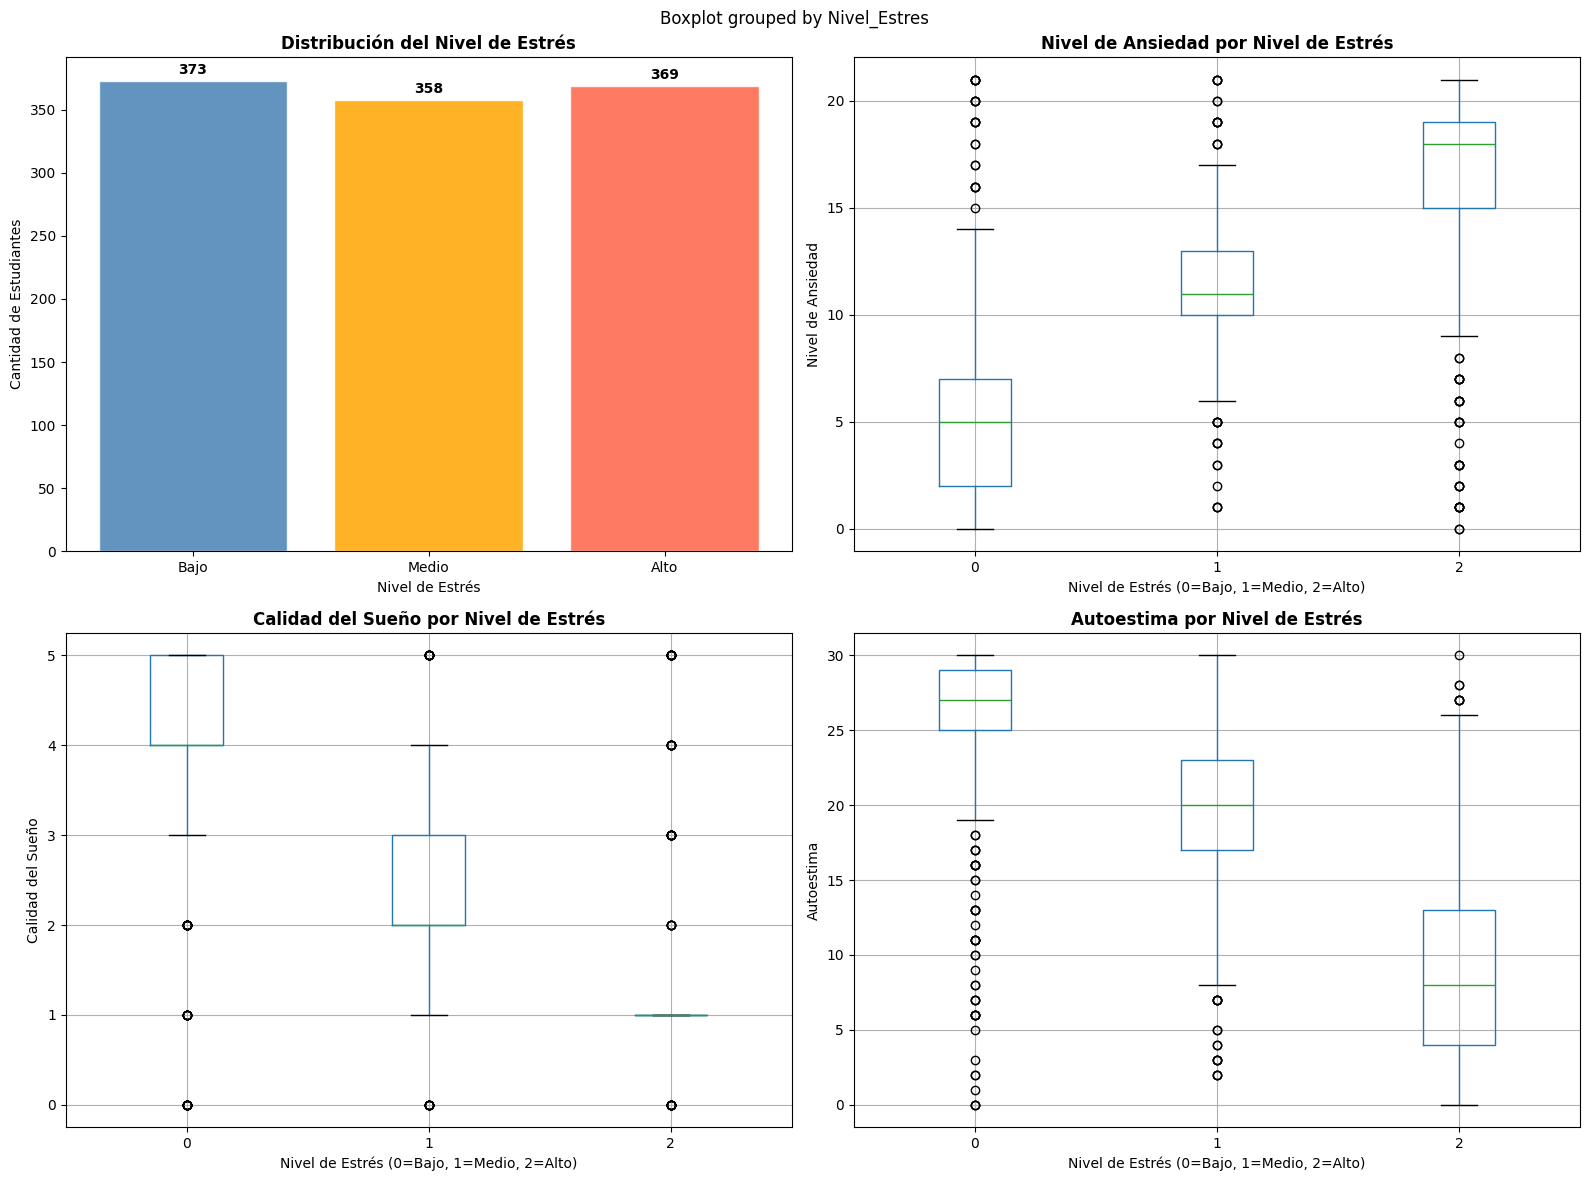

✓ Visualizaciones generadas exitosamente


In [11]:
# ============================================================
# CELDA 6 — Visualizaciones del EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis Exploratorio — Dataset de Estrés Estudiantil y Bienestar Mental',
             fontsize=16, fontweight='bold')

# --- GRÁFICO 1: Distribución del Nivel de Estrés (Bar Plot) ---
colores = ['steelblue', 'orange', 'tomato']
etiquetas = ['Bajo', 'Medio', 'Alto']
valores = df['Nivel_Estres'].value_counts().sort_index()
axes[0, 0].bar(etiquetas, valores.values, color=colores, edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Distribución del Nivel de Estrés', fontweight='bold')
axes[0, 0].set_xlabel('Nivel de Estrés')
axes[0, 0].set_ylabel('Cantidad de Estudiantes')
for i, v in enumerate(valores.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# --- GRÁFICO 2: Nivel de Ansiedad por Nivel de Estrés (Box Plot) ---
df.boxplot(column='Nivel_Ansiedad', by='Nivel_Estres', ax=axes[0, 1])
axes[0, 1].set_title('Nivel de Ansiedad por Nivel de Estrés', fontweight='bold')
axes[0, 1].set_xlabel('Nivel de Estrés (0=Bajo, 1=Medio, 2=Alto)')
axes[0, 1].set_ylabel('Nivel de Ansiedad')
plt.sca(axes[0, 1])
plt.title('Nivel de Ansiedad por Nivel de Estrés', fontweight='bold')

# --- GRÁFICO 3: Calidad del Sueño por Nivel de Estrés (Box Plot) ---
df.boxplot(column='Calidad_Sueno', by='Nivel_Estres', ax=axes[1, 0])
axes[1, 0].set_title('Calidad del Sueño por Nivel de Estrés', fontweight='bold')
axes[1, 0].set_xlabel('Nivel de Estrés (0=Bajo, 1=Medio, 2=Alto)')
axes[1, 0].set_ylabel('Calidad del Sueño')
plt.sca(axes[1, 0])
plt.title('Calidad del Sueño por Nivel de Estrés', fontweight='bold')

# --- GRÁFICO 4: Autoestima por Nivel de Estrés (Box Plot) ---
df.boxplot(column='Autoestima', by='Nivel_Estres', ax=axes[1, 1])
axes[1, 1].set_title('Autoestima por Nivel de Estrés', fontweight='bold')
axes[1, 1].set_xlabel('Nivel de Estrés (0=Bajo, 1=Medio, 2=Alto)')
axes[1, 1].set_ylabel('Autoestima')
plt.sca(axes[1, 1])
plt.title('Autoestima por Nivel de Estrés', fontweight='bold')

plt.tight_layout()
plt.savefig('visualizaciones_eda_estres.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Visualizaciones generadas exitosamente")

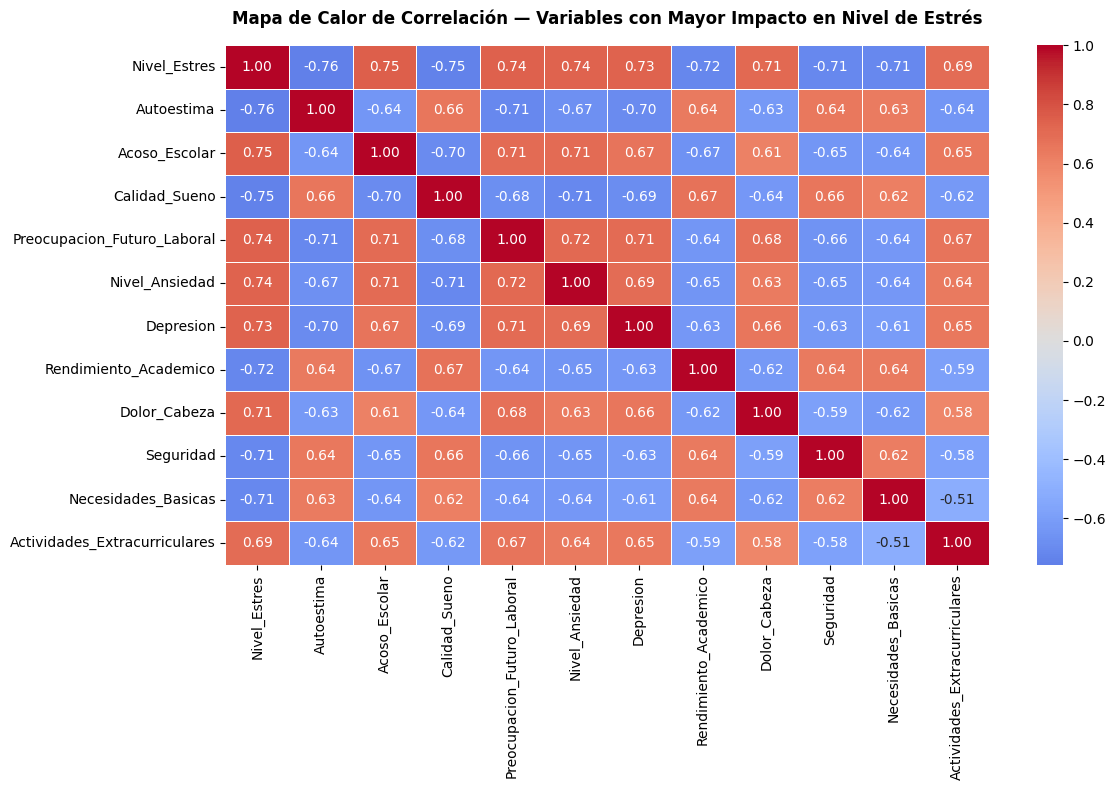

✓ Mapa de correlación generado exitosamente


In [12]:
# ============================================================
# CELDA 7 — Mapa de Calor de Correlación (Correlation Heatmap)
# ============================================================

# Calculamos las correlaciones de todas las variables con Nivel_Estres
correlaciones = df.corr()
top_correlaciones = correlaciones['Nivel_Estres'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[top_correlaciones].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Mapa de Calor de Correlación — Variables con Mayor Impacto en Nivel de Estrés',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlacion_estres.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Mapa de correlación generado exitosamente")

### Descripción General del Dataset
El dataset contiene 1.100 registros de estudiantes con 21 variables que miden
factores de bienestar mental, condiciones de entorno y síntomas físicos.
No se encontraron duplicados ni valores nulos, lo que indica un dataset
completo y listo para modelado. La variable objetivo (target) es Nivel_Estres con tres categorías: Bajo (373), Medio (358) y Alto (369), distribución
prácticamente balanceada que favorece el entrenamiento de modelos de
clasificación sin necesidad de técnicas de balanceo artificial.

### El Estrés como Respuesta Evolutiva
Antes de analizar los datos es fundamental entender qué es el estrés.
La Stress Response (Respuesta al Estrés) es un mecanismo de supervivencia
evolutivo conocido como Fight or Flight (Lucha o Huida), diseñado para
responder a amenazas físicas reales. El problema contemporáneo es que el
sistema nervioso no distingue entre una amenaza física y una amenaza
simbólica como la baja autoestima, el acoso escolar o la incertidumbre
laboral. El cuerpo activa la misma respuesta biológica ante un depredador
que ante una crítica social o una preocupación sobre el futuro. Los datos
confirman esta correlacion.

### Hallazgos Principales

**1. Amenazas simbólicas como principales predictores del estrés**
Las variables con mayor correlación con Nivel_Estres son Autoestima (-0.76),
Acoso_Escolar (0.75), Calidad_Sueno (-0.75) y Preocupacion_Futuro_Laboral
(0.74). La correlación negativa de Autoestima indica que a menor autoestima,
mayor nivel de estrés. Ninguna de estas variables representa una amenaza
física real, sino amenazas percibidas de naturaleza social, emocional y
económica, lo que confirma que el estrés moderno opera principalmente sobre
el sistema simbólico del individuo.

**2. Conexión entre síntomas físicos y mentales**
El dataset revela una correlación significativa entre variables físicas y
mentales: Dolor_Cabeza (0.71), Problema_Respiratorio y Presion_Arterial
correlacionan con el Nivel_Estres, mientras que también se correlacionan
con Nivel_Ansiedad y Depresion. Esto evidencia la Psychosomatic Response
(Respuesta Psicosomática): el estrés mental se manifiesta en síntomas físicos
y estos a su vez amplifican el malestar mental, generando un ciclo de sufrimiento que deteriora la salud integral del estudiante.

**3. El sueño como variable bisagra**
Calidad_Sueno presenta correlación de -0.75 con Nivel_Estres y correlaciones
significativas con prácticamente todas las variables del dataset. El sueño
deteriorado amplifica la ansiedad, la depresión y los síntomas físicos,
mientras que el estrés elevado destruye la calidad del sueño. Esta relación
bidireccional convierte al sueño en una variable bisagra cuya mejora podría
tener efecto cascada sobre el bienestar general.

**4. Actividades extracurriculares como factor protector**
Actividades_Extracurriculares presenta correlación de 0.69 con Nivel_Estres,
lo que a primera vista podría interpretarse como que más actividades generan
más estrés. Sin embargo en contexto esta correlación refleja que estudiantes
con mayor carga académica y social también participan más en actividades
extracurriculares, siendo la carga total el factor de estrés y no las
actividades en sí mismas, se evidencia las limitaciones del dataset al no definir qué son actividades extracurriculares.

**5. Dataset balanceado: ventaja para el modelado**
La distribución equilibrada de las tres clases de Nivel_Estres (Bajo: 373,
Medio: 358, Alto: 369) es una característica favorable para el entrenamiento
de modelos de Classification (Clasificación).

### Relevancia de la Meditación como Intervención
Las variables con mayor impacto en el estrés son exactamente las que la
práctica de meditación busca regular. Técnicas como el Body Scan
(Escaneo Corporal) actúan sobre la conexión mente-cuerpo reduciendo síntomas
físicos. La Focused Attention Meditation (Meditación de Atención Focalizada)
entrena al sistema nervioso a distinguir amenaza real de amenaza percibida.
El protocolo MAP Training (Entrenamiento Mental y Físico) combina meditación
con ejercicio aeróbico y tiene respaldo neurocientífico documentado en la
mejora de autoestima, reducción de ansiedad y calidad del sueño, las tres
variables más correlacionadas con el estrés en este dataset.

### Problemática Seleccionada
Se selecciona una problemática de Classification (Clasificación): predecir
el Nivel_Estres de un estudiante a partir de sus factores de bienestar,
entorno académico y salud mental. Esta problemática es relevante porque
permite identificar de forma temprana estudiantes en riesgo de estrés alto,
facilitando intervenciones preventivas como programas de meditación,
acompañamiento psicológico o ajuste de carga académica antes de que el
estrés se cronifique. Se podria hacer año a año para ir modulando por nivel y edad del estudiante